In [110]:
# import packages
import pandas as pd
import numpy as np
import yfinance as yf
from scipy import stats
import re, time
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from sklearn.covariance import LedoitWolf

# define constants
DATA_DIR = r'C:\Users\kaian\OneDrive\Desktop\RMT Finance Project\data'
OUTPUT_CSV = r'C:\Users\kaian\OneDrive\Desktop\RMT Finance Project\data\cleaned_congress_trades.csv'
PLOTS_DIR = r'C:\Users\kaian\OneDrive\Desktop\RMT Finance Project\plots'

VALID_RANGES = [
    '$1,001 - $15,000', '$15,001 - $50,000', '$50,001 - $100,000',
    '$100,001 - $250,000', '$250,001 - $500,000', '$500,001 - $1,000,000',
    '$1,000,001 - $5,000,000', '$5,000,001 - $25,000,000',
    '$25,000,001 - $50,000,000', 'Over $50,000,000',
]

In [ ]:
def clean_company_name(desc):
    desc = str(desc)
    desc = re.sub(r'\s*S\s*\(partial\).*$', '', desc, flags=re.IGNORECASE)
    desc = re.sub(r'\s*-\s*Common.*$', '', desc, flags=re.IGNORECASE)
    desc = re.sub(r'\s*Common Stock.*$', '', desc, flags=re.IGNORECASE)
    desc = re.sub(r'\s*Class [AB].*$', '', desc, flags=re.IGNORECASE)
    desc = re.sub(r'[,\-]+$', '', desc).strip()
    return desc

def lookup_ticker(company_name):
    try:
        results = yf.Search(company_name, max_results=1).quotes
        if results:
            return results[0].get('symbol', None)
    except Exception:
        pass
    return None

# ── Load raw lambda file ──────────────────────────────────────────────────
df = pd.read_csv(rf'{DATA_DIR}\lambda_trades.csv', low_memory=False)
print(f'Loaded lambda_trades.csv: {len(df):,} rows')

# ── Rows already carrying a valid ticker ─────────────────────────────────
VALID_TICKER = re.compile(r'^[A-Z]{1,5}$')
valid_mask = df['ticker'].apply(
    lambda t: bool(VALID_TICKER.match(str(t).strip())) if pd.notna(t) else False
)
print(f'Already have valid ticker: {valid_mask.sum():,} rows')

# ── Step 1: extract ticker from assetDescription — (TICKER) [ST/OP] ──────
def extract_paren_ticker(desc):
    if pd.isna(desc):
        return None
    m = re.search(r'\(([A-Z]{1,5})\)', str(desc))
    if m and re.search(r'\[(?:ST|OP)\]', str(desc)):
        return m.group(1)
    return None

null_mask = ~valid_mask
df.loc[null_mask, 'ticker'] = df.loc[null_mask, 'assetDescription'].apply(extract_paren_ticker)

after_regex = df['ticker'].apply(
    lambda t: bool(VALID_TICKER.match(str(t).strip())) if pd.notna(t) else False
).sum()
print(f'Recovered via regex (paren+bracket): {after_regex - valid_mask.sum():,} rows')

# ── Step 2: yfinance lookup for remaining null-ticker rows ────────────────
still_null = df['ticker'].apply(
    lambda t: not (bool(VALID_TICKER.match(str(t).strip())) if pd.notna(t) else False)
)
print(f'Still missing after regex: {still_null.sum():,} rows -> running yfinance lookup')

missing = df.loc[still_null].copy()
missing['clean_name'] = missing['assetDescription'].apply(clean_company_name)

# Filter out rows that are clearly bonds / munis (no parseable equity name)
# Heuristic: descriptions containing digits and % are prob fixed-income
bond_pattern = re.compile(r'\d+\.?\d*%|\bCNTY\b|\bMUNI\b|\bBOND\b|\bGO\b|\bREV\b|\bCERT\b', re.IGNORECASE)
equity_mask = ~missing['clean_name'].str.contains(bond_pattern, na=True)
to_lookup = missing.loc[equity_mask, 'clean_name'].dropna()
unique_names = to_lookup.unique()
print(f'Unique company names to look up (equities only): {len(unique_names):,}')

name_to_ticker = {}
for i, name in enumerate(unique_names):
    if i % 100 == 0:
        print(f'  [{i:>5}/{len(unique_names)}] {name}')
    name_to_ticker[name] = lookup_ticker(name)
    time.sleep(0.2)

print(f'\nyfinance returned a symbol for: {sum(v is not None for v in name_to_ticker.values()):,} / {len(name_to_ticker):,} names')

# Apply recovered tickers back
df.loc[missing.index[equity_mask], 'ticker'] = (
    missing.loc[equity_mask, 'clean_name'].map(name_to_ticker)
)

after_yf = df['ticker'].apply(
    lambda t: bool(VALID_TICKER.match(str(t).strip())) if pd.notna(t) else False
).sum()
print(f'Recovered via yfinance: {after_yf - after_regex:,} rows')

# ── Step 3: drop rows still missing a ticker ─────────────────────────────
before_drop = len(df)
valid_final = df['ticker'].apply(
    lambda t: bool(VALID_TICKER.match(str(t).strip())) if pd.notna(t) else False
)
df = df[valid_final].copy()
df['ticker'] = df['ticker'].str.strip().str.upper()
print(f'Dropped (no ticker after all steps): {before_drop - len(df):,} rows')

# ── Step 4: standardise transaction_type ─────────────────────────────────
tx_map = {
    'S (Partial)': 'Sale (Partial)',
    'S (Full)':    'Sale (Full)',
    'P':           'Purchase',
}
df['transaction_type'] = df['transaction_type'].replace(tx_map)
before_unk = len(df)
df = df[df['transaction_type'] != 'Unknown'].copy()
print(f'Dropped Unknown transaction_type: {before_unk - len(df):,} rows')

print(f'\nFinal shape: {df.shape}')
print(df['transaction_type'].value_counts().to_string())

# ── Save outputs ──────────────────────────────────────────────────────────
df.to_csv(rf'{DATA_DIR}\lambda_trades_clean.csv', index=False)
print(f'\nSaved -> lambda_trades_clean.csv')

pd.DataFrame(
    list(name_to_ticker.items()), columns=['company_name', 'ticker']
).to_csv(rf'{DATA_DIR}\name_ticker_lookup.csv', index=False)
print('Saved -> name_ticker_lookup.csv')


Loaded lambda_trades.csv: 287,000 rows
Already have valid ticker: 4,548 rows
Recovered via regex (paren+bracket): 0 rows
Still missing after regex: 282,452 rows -> running yfinance lookup
Unique company names to look up (equities only): 1,533
  [    0/1533] Abbott Laboratories
  [  100/1533] Air Products and Chemicals, Inc.
  [  200/1533] Hyatt Hotels Corporation
  [  300/1533] uper Micro Computer, Inc.
  [  400/1533] United Rentals, Inc.
  [  500/1533] GATX Corporation
  [  600/1533] ilicon Laboratories, Inc.
  [  700/1533] Harley-Davidson, Inc.
  [  800/1533] Pacur, LLC <div class="text-muted"> <em>Company:</em> Pacur, LLC &nbsp;(Oshkosh, WI) </div> <div class="text-muted"><em>Description:</em>&nbsp;Manufacturing - Plastic Extrusion</div>
  [  900/1533] Lord Abbbett Ultra Short Bd Fund
  [ 1000/1533] Pacer Trendpilot 450 ETF
  [ 1100/1533] COP-ConocoPhillips
  [ 1200/1533] PUT Standard &amp; Poors Dep Rec at 180
  [ 1300/1533] ^MWE (Exchanged) <br> MPLX LP (Received)
  [ 1400/1533] D

In [ ]:
# ============================================================
# EVENT STUDY — forward returns on senator purchases
# Steps:
#   1. Load existing cleaned trades + senate_scraped_trades.csv,
#      standardize columns, concat, deduplicate
#   2. Filter to Purchase rows with a valid ticker
#   3. Look up buy-day price; compute ret_10/20/30/60
#   4. Save to cleaned_congress_trades.csv
# ============================================================
def standardize_amount(value):
    if pd.isna(value): return None
    s = str(value).strip()
    if s in VALID_RANGES: return s
    nums = [float(n.replace(',', '')) for n in re.findall(r'[\d,]+\.?\d*', s) if n.replace(',', '')]
    if not nums: return None
    amt = max(nums)
    if amt <= 15000:       return '$1,001 - $15,000'
    if amt <= 50000:       return '$15,001 - $50,000'
    if amt <= 100000:      return '$50,001 - $100,000'
    if amt <= 250000:      return '$100,001 - $250,000'
    if amt <= 500000:      return '$250,001 - $500,000'
    if amt <= 1_000_000:   return '$500,001 - $1,000,000'
    if amt <= 5_000_000:   return '$1,000,001 - $5,000,000'
    if amt <= 25_000_000:  return '$5,000,001 - $25,000,000'
    if amt <= 50_000_000:  return '$25,000,001 - $50,000,000'
    return 'Over $50,000,000'

def clean_name(name):
    if not isinstance(name, str) or pd.isna(name): return name
    prefixes = ['Mr', 'Mrs', 'Ms', 'Dr', 'Sen', 'Rep']
    suffixes = ['Jr', 'Sr', 'II', 'III', 'IV', 'V']
    name = name.replace('.', '').strip()
    name = re.sub(r'^(?:' + '|'.join(prefixes) + r')\s+', '', name, flags=re.IGNORECASE)
    if ',' in name:
        parts = [p.strip() for p in name.split(',', 1)]
        name = f'{parts[1]} {parts[0]}'
    name = re.sub(r'\b(?:' + '|'.join(prefixes) + r')\b', '', name, flags=re.IGNORECASE)
    name = re.sub(r'\b(?:' + '|'.join(suffixes) + r')\b$', '', name, flags=re.IGNORECASE)
    return re.sub(r'\s+', ' ', name).strip()

DEDUP_COLS = ['owner_name', 'ticker', 'transaction_date', 'transaction_type', 'trade_value']

# ──────────────────────────────────────────────────────────
# STEP 1A  Existing sources
# ──────────────────────────────────────────────────────────
print('=' * 60)
print('STEP 1 - Load & standardise all sources')

df_24 = pd.read_csv(rf'{DATA_DIR}\senate_stock_disclosures.csv')
df_24.columns = df_24.columns.str.strip().str.lower().str.replace(' ', '_')
df_24['owner_name'] = df_24['first_name'].str.strip() + ' ' + df_24['last_name'].str.strip()
df_24['trade_value'] = (
    '$' + df_24['asset_value_low'].apply(lambda x: f'{int(x):,}') +
    ' - $' + df_24['asset_value_high'].apply(lambda x: f'{int(x):,}')
)
df_24 = df_24.rename(columns={'transaction': 'transaction_type'})
df_24['transaction_date'] = pd.to_datetime(df_24['transaction_date'], format='mixed', dayfirst=True)
df_24['trade_value'] = df_24['trade_value'].apply(standardize_amount)
df_24 = df_24[['ticker','asset_name','transaction_date','transaction_type','trade_value','asset_type','owner_name']].copy()
print(f'  senate_stock_disclosures: {len(df_24):,} rows')

df_23 = pd.read_csv(rf'{DATA_DIR}\trades_up_to_23.csv', encoding='latin-1')
df_23.columns = df_23.columns.str.strip().str.lower().str.replace(' ', '_')
df_23 = df_23.rename(columns={
    'company': 'asset_name', 'filed': 'transaction_date', 'transaction': 'transaction_type',
    'trade_size_usd': 'trade_value', 'tickertype': 'asset_type', 'name': 'owner_name'
})
df_23['transaction_date'] = pd.to_datetime(df_23['transaction_date'], format='mixed')
df_23['trade_value'] = df_23['trade_value'].apply(standardize_amount)
df_23['transaction_type'] = df_23['transaction_type'].replace({'Sale': 'Sale (Full)'})
df_23 = df_23[['ticker','asset_name','transaction_date','transaction_type','trade_value','asset_type','owner_name']].copy()
print(f'  trades_up_to_23:          {len(df_23):,} rows')

df_21 = pd.read_csv(rf'{DATA_DIR}\SenatorCleaned.csv')
df_21.columns = df_21.columns.str.strip().str.lower().str.replace('.', '_').str.replace(' ', '_')
df_21 = df_21.rename(columns={'type': 'transaction_type', 'amount': 'trade_value', 'name': 'owner_name'})
df_21['transaction_date'] = pd.to_datetime(df_21['transaction_date'], format='mixed')
df_21['trade_value'] = df_21['trade_value'].apply(standardize_amount)
df_21 = df_21[['ticker','asset_name','transaction_date','transaction_type','trade_value','asset_type','owner_name']].copy()
print(f'  SenatorCleaned:           {len(df_21):,} rows')

# ──────────────────────────────────────────────────────────
# STEP 1B  New scraped trades
# ──────────────────────────────────────────────────────────
df_new = pd.read_csv(rf'{DATA_DIR}\senate_scraped_trades.csv')
df_new['owner_name'] = df_new['first_name'].str.strip() + ' ' + df_new['last_name'].str.strip()
df_new = df_new.rename(columns={
    'tx_date': 'transaction_date',
    'tx_type': 'transaction_type',
    'amount':  'trade_value',
})
df_new['transaction_date'] = pd.to_datetime(df_new['transaction_date'], format='mixed')
df_new['trade_value'] = df_new['trade_value'].apply(standardize_amount)
if 'asset_type' not in df_new.columns:
    df_new['asset_type'] = 'Stock'
if 'asset_name' not in df_new.columns:
    df_new['asset_name'] = None
df_new = df_new[['ticker','asset_name','transaction_date','transaction_type','trade_value','asset_type','owner_name']].copy()
print(f'  senate_scraped_trades:    {len(df_new):,} rows')

# ──────────────────────────────────────────────────────────
# ──────────────────────────────────────────────────────────
# STEP 1C  Lambda Finance trades
# ──────────────────────────────────────────────────────────
df_lam = pd.read_csv(rf'{DATA_DIR}\lambda_trades_clean.csv', low_memory=False)
# lambda_trades_clean.csv already has:
#   - ticker recovered via regex (TICKER) [ST/OP] where possible
#   - null-ticker rows dropped (bonds, munis, unresolvable descriptions)
#   - transaction_type standardised and Unknown rows dropped
df_lam.columns = df_lam.columns.str.strip().str.lower().str.replace(' ', '_')
df_lam = df_lam.rename(columns={
    'member':           'owner_name',
    'amount':           'trade_value',
    'assetdescription': 'asset_name',
})
print(f'  lambda_trades_clean loaded:    {len(df_lam):,} rows')
df_lam['transaction_date'] = pd.to_datetime(df_lam['transaction_date'], format='mixed')
df_lam['trade_value'] = df_lam['trade_value'].apply(standardize_amount)
if 'asset_type' not in df_lam.columns:
    df_lam['asset_type'] = 'Stock'
if 'asset_name' not in df_lam.columns:
    df_lam['asset_name'] = None
df_lam = df_lam[['ticker','asset_name','transaction_date','transaction_type','trade_value','asset_type','owner_name']].copy()
print(f'  lambda_trades:            {len(df_lam):,} rows')

# ──────────────────────────────────────────────────────────
# STEP 1D  Concat + clean names + dedup
# ──────────────────────────────────────────────────────────
combined = pd.concat([df_24, df_23, df_21, df_new, df_lam], ignore_index=True)
print(f'\n  Combined before dedup:    {len(combined):,} rows')

combined['owner_name'] = combined['owner_name'].apply(clean_name)
combined['asset_type'] = combined['asset_type'].replace({'ST': 'Stock', 'OP': 'Stock Option'})

before_dedup = len(combined)
combined = combined.drop_duplicates(subset=DEDUP_COLS, keep='first')
print(f'  After dedup:              {len(combined):,} rows  ({before_dedup - len(combined):,} dupes removed)')
print(f'  Source counts -> disclosures: {len(df_24):,}  up_to_23: {len(df_23):,}  SenatorCleaned: {len(df_21):,}  scraped: {len(df_new):,}  lambda: {len(df_lam):,}')

# ──────────────────────────────────────────────────────────
# STEP 2  Filter to Purchases on Stock assets with valid ticker
# ──────────────────────────────────────────────────────────
print()
print('=' * 60)
print('STEP 2 — Filter to Purchases with valid ticker')

s0 = len(combined)
purchases = combined[combined['transaction_type'] == 'Purchase'].copy()
print(f'  Purchase rows:            {len(purchases):,}  (dropped {s0 - len(purchases):,} non-purchases)')

s1 = len(purchases)
purchases = purchases[purchases['asset_type'].str.lower().isin(['stock'])].copy()
print(f'  After Stock filter:       {len(purchases):,}  (dropped {s1 - len(purchases):,} non-stock)')

s2 = len(purchases)
purchases = purchases[
    purchases['ticker'].notna() &
    (purchases['ticker'].str.strip() != '--') &
    (purchases['ticker'].str.strip() != '')
].copy()
purchases['ticker'] = purchases['ticker'].str.strip().str.upper()
print(f'  After valid-ticker filter:{len(purchases):,}  (dropped {s2 - len(purchases):,} bad tickers)')

# ──────────────────────────────────────────────────────────
# STEP 3  CAPM-adjusted CARs
# ──────────────────────────────────────────────────────────
print()
print('=' * 60)
print('STEP 3 — CAPM-adjusted CARs')

# ── 3a. Load price table ───────────────────────────────────
print('  Loading price table…')
prices = pd.read_csv(
    rf'{DATA_DIR}\\all_stock_data.csv',
    usecols=['Date', 'Ticker', 'Close'],
    parse_dates=['Date']
)
prices = prices.rename(columns={'Date': 'date', 'Ticker': 'ticker', 'Close': 'close'})
prices['ticker'] = prices['ticker'].str.strip().str.upper()
prices = (
    prices[prices['close'].notna()]
    .sort_values(['ticker', 'date'])
    .reset_index(drop=True)
)
print(f'  Price rows loaded:             {len(prices):,}')

# per-ticker date/close arrays and daily-return arrays
ticker_close_dates = {}
ticker_close_vals  = {}
ticker_ret_dates   = {}
ticker_ret_vals    = {}
for _tkr, _grp in prices.groupby('ticker', sort=False):
    _s = _grp.set_index('date')['close'].sort_index().replace(0, np.nan)
    ticker_close_dates[_tkr] = _s.index.values
    ticker_close_vals[_tkr]  = _s.values
    _r = _s.ffill().pct_change(fill_method=None).dropna()
    ticker_ret_dates[_tkr]   = _r.index.values
    ticker_ret_vals[_tkr]    = _r.values

def lookup_close(ticker, target_date):
    if ticker not in ticker_close_dates: return np.nan
    d = ticker_close_dates[ticker]
    i = int(np.searchsorted(d, np.datetime64(target_date, 'ns'), side='left'))
    return np.nan if i >= len(d) else float(ticker_close_vals[ticker][i])

# SPY series
spy_ret   = pd.Series(
    ticker_ret_vals['SPY'],
    index=pd.DatetimeIndex(ticker_ret_dates['SPY'])
)
print(f'  SPY trading days:              {len(spy_ret):,}')

# ── 3b. Fetch risk-free rate from FRED ───────────────────
print('  Fetching DTB3 from FRED…')
import io, urllib.request
FRED_URL = 'https://fred.stlouisfed.org/graph/fredgraph.csv?id=DTB3'
_fred_raw = urllib.request.urlopen(FRED_URL, timeout=30).read()
rf_daily = pd.read_csv(
    io.BytesIO(_fred_raw),
    parse_dates=['observation_date']
).rename(columns={'observation_date': 'date', 'DTB3': 'rf_ann'})
rf_daily = rf_daily[rf_daily['rf_ann'] != '.'].copy()
rf_daily['rf_ann'] = pd.to_numeric(rf_daily['rf_ann'], errors='coerce')
rf_daily = rf_daily.dropna(subset=['rf_ann'])
# annualised % → daily decimal: (1 + r/100)^(1/252) - 1
rf_daily['rf'] = (1 + rf_daily['rf_ann'] / 100) ** (1 / 252) - 1
rf_daily = rf_daily.set_index('date')['rf'].sort_index()
# forward-fill over weekends / holidays (max 3 calendar days)
rf_daily = rf_daily.reindex(
    pd.date_range(rf_daily.index.min(), rf_daily.index.max(), freq='D')
).ffill(limit=3)
print(f'  Risk-free rate rows (after ffill): {rf_daily.notna().sum():,}')
print(f'  RF date range: {rf_daily.dropna().index.min().date()} → {rf_daily.dropna().index.max().date()}')

def get_rf(date):
    """Daily risk-free rate for a given date (0 if missing)."""
    ts = pd.Timestamp(date)
    return float(rf_daily.get(ts, 0.0))

# ── 3c. Buy-day close price ─────────────────────────────────
purchases['transaction_date'] = pd.to_datetime(purchases['transaction_date'])
print('  Looking up buy-day prices…')
purchases['price_buy'] = [
    lookup_close(r.ticker, r.transaction_date)
    for r in purchases.itertuples(index=False)
]
s3 = len(purchases)
purchases = purchases[purchases['price_buy'].notna()].copy()
print(f'  After buy-price filter:        {len(purchases):,}  (dropped {s3 - len(purchases):,})')

# ── 3d. Per-event CAPM beta estimation + CAR computation ────────
# Estimation window: 252 trading days ending 30 calendar days before event
EST_DAYS      = 252
PRE_EVENT_GAP = pd.Timedelta(days=30)
MIN_OBS       = 60
HORIZONS      = [10, 20, 30, 60]

print('  Estimating betas and computing CARs…')

results = []          # one dict per row
n_dropped_min_obs = 0

for row in purchases.itertuples(index=False):
    tkr       = row.ticker
    event_dt  = row.transaction_date

    # estimation window
    est_end   = event_dt - PRE_EVENT_GAP

    # stock returns in window
    if tkr not in ticker_ret_dates:
        n_dropped_min_obs += 1
        continue
    t_rd = ticker_ret_dates[tkr];  t_rv = ticker_ret_vals[tkr]
    mask_est_end = np.searchsorted(t_rd, np.datetime64(est_end, 'ns'), side='right')
    mask_est_sta = max(0, mask_est_end - EST_DAYS)
    stk_est = pd.Series(t_rv[mask_est_sta:mask_est_end],
                        index=pd.DatetimeIndex(t_rd[mask_est_sta:mask_est_end]))

    # align SPY to same dates
    spy_est = spy_ret.reindex(stk_est.index)
    rf_est  = pd.Series([get_rf(d) for d in stk_est.index], index=stk_est.index)

    # excess returns
    stk_ex  = stk_est - rf_est
    spy_ex  = spy_est - rf_est
    common  = stk_ex.notna() & spy_ex.notna()

    if common.sum() < MIN_OBS:
        n_dropped_min_obs += 1
        continue

    # OLS: stk_ex = alpha + beta * spy_ex  (no intercept needed for only beta)
    X = spy_ex[common].values
    Y = stk_ex[common].values
    beta = float(np.dot(X, Y) / np.dot(X, X))   # OLS slope, no intercept

    # ── event window CARs ─────────────────────────────────
    rec = {'idx': row.Index if hasattr(row, 'Index') else None, 'beta': beta}

    for h in HORIZONS:
        h_end = event_dt + pd.Timedelta(days=h)
        # stock return slice for event window
        e0 = int(np.searchsorted(t_rd, np.datetime64(event_dt, 'ns'), side='left'))
        e1 = int(np.searchsorted(t_rd, np.datetime64(h_end,    'ns'), side='right'))
        if e1 <= e0:
            rec[f'car_{h}'] = np.nan
            continue
        stk_ev  = pd.Series(t_rv[e0:e1], index=pd.DatetimeIndex(t_rd[e0:e1]))
        spy_ev  = spy_ret.reindex(stk_ev.index)
        rf_ev   = pd.Series([get_rf(d) for d in stk_ev.index], index=stk_ev.index)
        valid   = stk_ev.notna() & spy_ev.notna()
        if not valid.any():
            rec[f'car_{h}'] = np.nan
            continue
        # daily abnormal return = R_stock - (R_f + beta*(R_spy - R_f))
        ar = (stk_ev[valid].values
              - (rf_ev[valid].values
                 + beta * (spy_ev[valid].values - rf_ev[valid].values)))
        rec[f'car_{h}'] = float(ar.sum())

    results.append(rec)

print(f'  Dropped (< {MIN_OBS} estimation obs):  {n_dropped_min_obs:,}')
print(f'  Events with beta estimated:    {len(results):,}')

# Merge results back
res_df = pd.DataFrame(results)
purchases = purchases.reset_index(drop=True)
for col in [f'car_{h}' for h in HORIZONS] + ['beta']:
    purchases[col] = np.nan

if len(res_df) and 'idx' in res_df.columns and res_df['idx'].notna().all():
    purchases.loc[res_df['idx'].values, [f'car_{h}' for h in HORIZONS] + ['beta']] = \
        res_df[[f'car_{h}' for h in HORIZONS] + ['beta']].values
else:
    # fallback: results are in order of surviving rows
    surviving_mask = ~purchases.index.isin([])
    # re-run tracking which original rows survived
    purchases = purchases.reset_index(drop=True)
    surviving_idxs = []
    _n_drop = 0
    for _i, row in enumerate(purchases.itertuples(index=True)):
        tkr = row.ticker; event_dt = row.transaction_date
        est_end = event_dt - PRE_EVENT_GAP
        if tkr not in ticker_ret_dates: _n_drop += 1; continue
        t_rd = ticker_ret_dates[tkr]; t_rv = ticker_ret_vals[tkr]
        me = np.searchsorted(t_rd, np.datetime64(est_end, 'ns'), side='right')
        ms = max(0, me - EST_DAYS)
        stk_e = pd.Series(t_rv[ms:me], index=pd.DatetimeIndex(t_rd[ms:me]))
        spy_e = spy_ret.reindex(stk_e.index)
        rf_e  = pd.Series([get_rf(d) for d in stk_e.index], index=stk_e.index)
        c = (stk_e - rf_e).notna() & (spy_e - rf_e).notna()
        if c.sum() < MIN_OBS: _n_drop += 1; continue
        surviving_idxs.append(row.Index)
    for _j, _idx in enumerate(surviving_idxs):
        for col in [f'car_{h}' for h in HORIZONS] + ['beta']:
            purchases.at[_idx, col] = res_df.iloc[_j][col] if col in res_df.columns else np.nan

# drop rows where beta estimation failed
before_drop = len(purchases)
purchases = purchases[purchases['beta'].notna()].copy()
print(f'  Final rows after min-obs drop: {len(purchases):,}  (removed {before_drop - len(purchases):,})')

car_cols = [f'car_{h}' for h in HORIZONS]
all4   = purchases[car_cols].notna().all(axis=1).sum()
any1   = purchases[car_cols].notna().any(axis=1).sum()
print(f'  Rows with all 4 CARs:          {all4:,}')
print(f'  Rows with >= 1 CAR:            {any1:,}')
print(f'  Rows with no CARs:             {len(purchases) - any1:,}  (event window outside price data)')
print()
print('  CAPM CAR summary stats:')
print(purchases[car_cols].describe().round(4).to_string())

# ──────────────────────────────────────────────────────────
# STEP 4  Save
# ──────────────────────────────────────────────────────────
print()
print('=' * 60)
print('STEP 4 — Save')

out_cols = ['owner_name', 'ticker', 'asset_name', 'transaction_date',
            'trade_value', 'price_buy', 'beta', 'car_10', 'car_20', 'car_30', 'car_60']
purchases[out_cols].to_csv(OUTPUT_CSV, index=False)
print(f'  Saved {len(purchases):,} rows -> cleaned_congress_trades.csv')

# ──────────────────────────────────────────────────────────
# STEP 5  CAR t-tests  (H0: mean CAR = 0)
# ──────────────────────────────────────────────────────────
from scipy import stats

print()
print('=' * 60)
print('STEP 5 — CAR t-tests  (H0: mean CAR = 0)')

CAR_COLS = ['car_10', 'car_20', 'car_30', 'car_60']
HORIZONS = [10, 20, 30, 60]

def print_ttest_table(df, label):
    print(f'{label}')
    print(f'  {"Horizon":<10} {"n":>7} {"Mean CAR":>12} {"t-stat":>10} {"p-value":>10}  {"sig":>4}')
    print('  ' + '-' * 58)
    for h, col in zip(HORIZONS, CAR_COLS):
        vals = df[col].dropna()
        n = len(vals)
        if n < 2:
            print(f'  CAR-{h:<6} {n:>7}  {"n/a":>11}  {"n/a":>9}  {"n/a":>9}')
            continue
        t, p = stats.ttest_1samp(vals, popmean=0)
        sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
        print(f'  CAR-{h:<6} {n:>7} {vals.mean()*100:>11.3f}%  {t:>9.3f}  {p:>9.4f}  {sig:>4}')

# All events
print_ttest_table(purchases, 'All events')

# Split by transaction type
for tx_type in ['Purchase', 'Sale (Full)', 'Sale (Partial)']:
    subset = purchases[purchases['transaction_type'] == tx_type] if 'transaction_type' in purchases.columns else pd.DataFrame()
    if len(subset) >= 2:
        print_ttest_table(subset, f'transaction_type = {tx_type}  (n={len(subset):,})')

print()
print('  Significance: * p<0.10  ** p<0.05  *** p<0.01')

# ──────────────────────────────────────────────────────────
# STEP 5B  CAR-30 subgroup t-tests
# Purpose: verify the weighting scheme identifies higher-signal trades
# ──────────────────────────────────────────────────────────
print()
print('=' * 60)
print('STEP 5B — CAR-30 subgroup t-tests')
print('  (H0: mean CAR-30 = 0 within each subgroup)')

def ttest_car30(df, label):
    vals = df['car_30'].dropna()
    n = len(vals)
    if n < 2:
        print(f'  {label:<52} n={n:>5}  (insufficient data)')
        return
    t, p = stats.ttest_1samp(vals, popmean=0)
    sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
    print(f'  {label:<52} n={n:>5}  mean={vals.mean()*100:>+7.3f}%  '
          f't={t:>7.3f}  p={p:>7.4f}  {sig}')

print()
print(f'  {"Subgroup":<52} {"n":>6}  {"Mean CAR-30":>10}  {"t-stat":>7}  {"p-value":>7}  sig')
print('  ' + '-' * 90)

# ── Derive subgroup columns from purchases in memory ─────────────────────
# (1) n_members: unique senators buying same ticker across whole dataset
ticker_member_counts = (
    purchases.groupby('ticker')['owner_name']
    .nunique()
    .rename('n_members')
)
purchases = purchases.join(ticker_member_counts, on='ticker')

# (2) member quality weight (w_member): proportional to mean CAR-30 per senator
member_mean_car = purchases.groupby('owner_name')['car_30'].mean()
purchases['w_member_q'] = purchases['owner_name'].map(member_mean_car)

# (3) cluster flag: >=1 OTHER senator bought the same ticker within 30 days
purchases = purchases.sort_values(['ticker', 'transaction_date']).reset_index(drop=True)
cluster_flags = []
for row in purchases.itertuples(index=False):
    same_tkr = purchases[
        (purchases['ticker'] == row.ticker) &
        (purchases['owner_name'] != row.owner_name)
    ]
    diff_days = (same_tkr['transaction_date'] - row.transaction_date).dt.days.abs()
    cluster_flags.append(int((diff_days <= 30).any()))
purchases['is_cluster'] = cluster_flags

# ── (1) n_members >= 4 vs n_members == 3 ─────────────────────────────────
print('  [1] Ticker conviction (unique senators buying same ticker)')
ttest_car30(purchases[purchases['n_members'] >= 4], 'n_members >= 4  (high conviction)')
ttest_car30(purchases[purchases['n_members'] == 3], 'n_members == 3  (min-threshold)')

# ── (2) Top vs bottom tercile of member quality weight ────────────────────
print()
print('  [2] Senator quality (mean CAR-30 of buying senator)')
q33 = purchases['w_member_q'].quantile(1/3)
q67 = purchases['w_member_q'].quantile(2/3)
ttest_car30(purchases[purchases['w_member_q'] >= q67], 'Top tercile member quality')
ttest_car30(purchases[purchases['w_member_q'] <= q33], 'Bottom tercile member quality')

# ── (3) Cluster vs non-cluster trades ────────────────────────────────────
print()
print('  [3] Coordinated buying (multiple senators, same ticker, within 30 days)')
ttest_car30(purchases[purchases['is_cluster'] == 1], 'Cluster trades (coordinated)')
ttest_car30(purchases[purchases['is_cluster'] == 0], 'Non-cluster trades (isolated)')

print()
print('Complete.')


STEP 1 - Load & standardise all sources
  senate_stock_disclosures: 4,699 rows
  trades_up_to_23:          46,467 rows
  SenatorCleaned:           15,666 rows
  senate_scraped_trades:    15,363 rows
  lambda_trades_clean loaded:    56,740 rows
  lambda_trades:            56,740 rows

  Combined before dedup:    138,935 rows
  After dedup:              61,285 rows  (77,650 dupes removed)
  Source counts -> disclosures: 4,699  up_to_23: 46,467  SenatorCleaned: 15,666  scraped: 15,363  lambda: 56,740

STEP 2 — Filter to Purchases with valid ticker
  Purchase rows:            30,211  (dropped 31,074 non-purchases)
  After Stock filter:       22,304  (dropped 7,907 non-stock)
  After valid-ticker filter:22,090  (dropped 214 bad tickers)

STEP 3 — CAPM-adjusted CARs
  Loading price table…
  Price rows loaded:             34,646,152
  SPY trading days:              7,998
  Fetching DTB3 from FRED…
  Risk-free rate rows (after ffill): 26,390
  RF date range: 1954-01-04 → 2026-04-09
  Looking u

In [ ]:
import pandas as pd
import numpy as np

DATA_DIR = r'C:\Users\kaian\OneDrive\Desktop\RMT Finance Project\data'

trades = pd.read_csv(rf'{DATA_DIR}\cleaned_congress_trades.csv', parse_dates=['transaction_date'])
trades['transaction_date'] = pd.to_datetime(trades['transaction_date'])

# ── Weights ─────────────────────────────────────────────────
amount_map = {
    '$1,001 - $15,000':    (1_001,    15_000),
    '$15,001 - $50,000':   (15_001,   50_000),
    '$50,001 - $100,000':  (50_001,  100_000),
    '$100,001 - $250,000': (100_001, 250_000),
    '$250,001 - $500,000': (250_001, 500_000),
    '$500,001 - $1,000,000': (500_001, 1_000_000),
    '$1,000,001 - $5,000,000': (1_000_001, 5_000_000),
    '$5,000,001 - $25,000,000': (5_000_001, 25_000_000),
    '$25,000,001 - $50,000,000': (25_000_001, 50_000_000),
}
def size_weight(amt_str):
    r = amount_map.get(str(amt_str).strip())
    if r is None:
        return 1.0
    return np.log1p(np.sqrt(r[0] * r[1]))

trades['w_size'] = trades['trade_value'].apply(size_weight)

member_mean = trades.groupby('owner_name')['car_30'].mean()
trades['w_member'] = trades['owner_name'].map(member_mean)
trades['w_member'] = (trades['w_member'] - trades['w_member'].mean()) + 1.0
trades['w_member'] = trades['w_member'].clip(lower=0.01)

def cluster_weight(grp):
    dates = grp['transaction_date'].values
    names = grp['owner_name'].values
    result = []
    for i in range(len(grp)):
        diff_days = np.abs((dates - dates[i]).astype('timedelta64[D]').astype(int))
        mask = (names != names[i]) & (diff_days <= 30)
        result.append(int(mask.sum()) + 1)
    return pd.Series(result, index=grp.index)

trades['w_cluster'] = trades.groupby('ticker', group_keys=False).apply(cluster_weight)
trades['weight'] = trades['w_size'] * trades['w_member'] * trades['w_cluster']

# ── Raw weighted CAR-30 and event count per ticker ──────────
def weighted_stats(g):
    w = g['weight']
    return pd.Series({
        'raw_mu':    (w * g['car_30']).sum() / w.sum(),
        'n_events':  len(g),
        'n_members': g['owner_name'].nunique(),
        'car30_std': g['car_30'].std(),
    })

ticker_stats = trades.groupby('ticker', group_keys=False).apply(weighted_stats, include_groups=False)

# ── (1) Diagnostic: top 20 by raw weighted CAR-30 ──────────
print('Top 20 tickers by raw weighted CAR-30 (before any filter):')
print(f'  {"Ticker":<8} {"raw_mu":>10}  {"n_events":>10}  {"n_members":>10}  {"car30_std":>10}')
print('  ' + '-' * 56)
top20_raw = ticker_stats.sort_values('raw_mu', ascending=False).head(20)
for tkr, row in top20_raw.iterrows():
    print(f'  {tkr:<8} {row["raw_mu"]:>10.4f}  {int(row["n_events"]):>10}  {int(row["n_members"]):>10}  {row["car30_std"]:>10.4f}')

# ── (2) Minimum event filter: >= 3 purchase events ──────────
n_before = len(ticker_stats)
ticker_stats = ticker_stats[ticker_stats['n_events'] >= 3]
n_after = len(ticker_stats)
print(f'\nEvent filter (n_events >= 3): {n_before} -> {n_after} tickers  |  dropped {n_before - n_after}')

# ── (3) Minimum member filter: >= 3 unique members ──────────
n_before = len(ticker_stats)
ticker_stats = ticker_stats[ticker_stats['n_members'] >= 3]
n_after = len(ticker_stats)
print(f'Member filter (n_members >= 3): {n_before} -> {n_after} tickers  |  dropped {n_before - n_after}')

# ── (4) Noise filter: std(CAR-30) < 0.5 for tickers with < 5 events ──────
n_before = len(ticker_stats)
sparse_mask = ticker_stats['n_events'] < 5
noisy_mask  = ticker_stats['car30_std'] >= 0.5
drop_mask   = sparse_mask & noisy_mask
ticker_stats = ticker_stats[~drop_mask]
n_after = len(ticker_stats)
print(f'Noise filter (n_events<5 & std>=0.5): {n_before} -> {n_after} tickers  |  dropped {n_before - n_after}')

# ── (5) Recency filter: zero out tickers with no purchase in past 2 years ───
# Formation date for static cell = day after the most recent trade in the dataset
formation_date_static = trades['transaction_date'].max() + pd.Timedelta(days=1)
recency_cutoff = formation_date_static - pd.DateOffset(years=2)
recent_tickers = set(trades[trades['transaction_date'] >= recency_cutoff]['ticker'].unique())
stale_mask = ~ticker_stats.index.isin(recent_tickers)
n_stale = int(stale_mask.sum())
ticker_stats = ticker_stats.copy()
ticker_stats.loc[stale_mask, 'raw_mu'] = 0.0
print(f'Recency filter (>=1 purchase in past 2yr): {n_stale} tickers zeroed out of {len(ticker_stats)}')

# ── (6) Soft-clip with tanh transformation ───────────────────────
# mu_clipped = mu_std * tanh(raw_mu / mu_std)
# Preserves ranking, smoothly compresses extremes, no two tickers share exactly the same value.
raw_mu_series = ticker_stats['raw_mu']
mu_std_raw = float(raw_mu_series.std())
ticker_stats = ticker_stats.copy()
ticker_stats['mu_tanh'] = mu_std_raw * np.tanh(raw_mu_series / mu_std_raw)

print(f'\nTanh soft-clip (mu_std_raw={mu_std_raw:.4f}):')
print(f'  raw_mu  range: [{raw_mu_series.min():.4f}, {raw_mu_series.max():.4f}]')
print(f'  tanh    range: [{ticker_stats["mu_tanh"].min():.4f}, {ticker_stats["mu_tanh"].max():.4f}]')
print(f'  unique tanh values in top 20: '
      f'{ticker_stats["mu_tanh"].nlargest(20).nunique()} (was capped at {(raw_mu_series >= raw_mu_series.quantile(0.99)).sum()} under hard winsor)')

# ── (6) Scale to covariance matrix units ──────────────────────
cov_full_diag = np.load(rf'{DATA_DIR}\cov_clean.npy')
mean_daily_vol = float(np.sqrt(np.diag(cov_full_diag)).mean())

tanh_mu = ticker_stats['mu_tanh']
mu_series = (tanh_mu - tanh_mu.mean()) / tanh_mu.std() * mean_daily_vol
mu_series.name = 'mu'

print(f'Scaled to cov units (mean daily vol = {mean_daily_vol*100:.4f}%):')
print(f'  mu range: [{mu_series.min():.6f}, {mu_series.max():.6f}]')
print(f'  mu std:    {mu_series.std():.6f}')

# ── Save ────────────────────────────────────────────────────
mu_series.to_csv(rf'{DATA_DIR}\ticker_mu.csv', header=True)
print(f'\nSaved ticker_mu.csv')


C:\Users\kaian\AppData\Local\Temp\ipykernel_14016\3788978834.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trades['w_cluster'] = trades.groupby('ticker', group_keys=False).apply(cluster_weight)


Top 20 tickers by raw weighted CAR-30 (before any filter):
  Ticker       raw_mu    n_events   n_members   car30_std
  --------------------------------------------------------
  GME          1.0846           4           4      0.9952
  KPLT         0.6495           2           1      0.0000
  QDEL         0.6489           3           3      0.2607
  AXSM         0.6249           1           1         nan
  CCS          0.5884           1           1         nan
  PLCE         0.5825           1           1         nan
  TMHC         0.5332           1           1         nan
  DOMO         0.4890           2           2      0.2044
  NGD          0.4122           1           1         nan
  RLMD         0.3729           1           1         nan
  ESNT         0.3729           1           1         nan
  FVRR         0.3616           1           1         nan
  EXPI         0.3420           2           1      0.2303
  MED          0.3263           1           1         nan
  MHLD      

In [ ]:
import pandas as pd
import numpy as np
from sklearn.covariance import LedoitWolf

DATA_DIR = r'C:\Users\kaian\OneDrive\Desktop\RMT Finance Project\data'

# ── 1. Load mu index and prices ──────────────────────────────────────────────
mu = pd.read_csv(rf'{DATA_DIR}\ticker_mu.csv', index_col=0)['mu']
mu_tickers = set(mu.index.str.upper())
print(f'mu tickers: {len(mu_tickers):,}')

print('Loading prices...')
prices = pd.read_csv(
    rf'{DATA_DIR}\all_stock_data.csv',
    usecols=['Date', 'Ticker', 'Close'],
    parse_dates=['Date'],
)
prices['Ticker'] = prices['Ticker'].str.strip().str.upper()
prices = prices[prices['Ticker'].isin(mu_tickers)]

# Restrict to 2012-onwards: gives enough T relative to N for a sensible q=N/T ratio
prices = prices[prices['Date'].dt.year >= 2012]

# ── 2. Pivot to wide log-return matrix, drop >20% missing tickers ────────────
close = prices.pivot_table(index='Date', columns='Ticker', values='Close')
close = close.sort_index()
close = close.where(close > 0, np.nan)  # zero and negative prices are corrupt data
log_ret = np.log(close / close.shift(1)).dropna(how='all')

miss_pct = log_ret.isna().mean()
keep_mask = miss_pct <= 0.20
n_dropped_missing = (~keep_mask).sum()
log_ret = log_ret.loc[:, keep_mask]

T, N = log_ret.shape
q = N / T
print(f'Wide log-return matrix: T={T:,} days x N={N:,} tickers')
print(f'Dropped (>20% missing): {n_dropped_missing:,} tickers')
print(f'q = N/T = {q:.4f}')

# Fill remaining intra-series gaps with zeros (non-trading days for thin stocks)
log_ret = log_ret.fillna(0.0)

# ── 3. Ledoit-Wolf shrinkage ──────────────────────────────────────────────────
print('Fitting Ledoit-Wolf shrinkage...')
lw = LedoitWolf(assume_centered=False)
lw.fit(log_ret.values)
cov_lw = lw.covariance_          # shape (N, N)
print(f'LW shrinkage coefficient alpha: {lw.shrinkage_:.6f}')

# ── 4. RMT cleaning via Marchenko-Pastur ─────────────────────────────────────
# Eigendecompose the LW covariance
eigenvalues, eigenvectors = np.linalg.eigh(cov_lw)  # ascending order

# Marchenko-Pastur bounds for the bulk (noise) eigenvalues
# Using the variance of the LW matrix (trace / N) as sigma^2
sigma2 = np.trace(cov_lw) / N
lambda_plus  = sigma2 * (1 + np.sqrt(q)) ** 2
lambda_minus = sigma2 * (1 - np.sqrt(q)) ** 2

noise_mask   = eigenvalues <= lambda_plus
signal_mask  = ~noise_mask
n_noise      = noise_mask.sum()
n_signal     = signal_mask.sum()

# ── 5. Eigenvalue diagnostics ────────────────────────────────────────────────
print()
print('=' * 55)
print('EIGENVALUE DIAGNOSTICS')
print('=' * 55)
print(f'  Marchenko-Pastur bounds: [{lambda_minus:.6f}, {lambda_plus:.6f}]')
print(f'  sigma^2 (trace/N):       {sigma2:.6f}')
print(f'  q = N/T:                 {q:.4f}')
print(f'  Total eigenvalues:       {N}')
print(f'  Noise eigenvalues:       {n_noise}  (will be replaced by bulk mean)')
print(f'  Signal eigenvalues:      {n_signal}')
print(f'  Variance explained by signal: '
      f'{eigenvalues[signal_mask].sum() / eigenvalues.sum() * 100:.1f}%')
print()
print('  Largest 10 eigenvalues (signal):')  
for ev in sorted(eigenvalues[signal_mask], reverse=True)[:10]:
    print(f'    {ev:.6f}')
print()
print(f'  Noise bulk: min={eigenvalues[noise_mask].min():.6f}  '
      f'max={eigenvalues[noise_mask].max():.6f}  '
      f'mean={eigenvalues[noise_mask].mean():.6f}')
print('=' * 55)

# Replace noise eigenvalues with their mean (preserves trace of noise subspace)
eigenvalues_clean = eigenvalues.copy()
noise_mean = eigenvalues[noise_mask].mean()
eigenvalues_clean[noise_mask] = noise_mean

# Reconstruct cleaned covariance: V @ diag(lambda_clean) @ V^T
cov_clean = eigenvectors @ np.diag(eigenvalues_clean) @ eigenvectors.T

# Force symmetry (guard against floating-point asymmetry)
cov_clean = (cov_clean + cov_clean.T) / 2

# Verify positive semi-definiteness
min_eig_clean = np.linalg.eigvalsh(cov_clean).min()
print(f'Min eigenvalue of cleaned matrix: {min_eig_clean:.2e}  (should be > 0)')

# ── 6. Save ───────────────────────────────────────────────────────────────────
tickers_kept = log_ret.columns.tolist()

np.save(rf'{DATA_DIR}\cov_clean.npy', cov_clean)
pd.Series(tickers_kept, name='ticker').to_csv(
    rf'{DATA_DIR}\cov_tickers.csv', index=False)

print(f'\nSaved cov_clean.npy  shape={cov_clean.shape}')
print(f'Saved cov_tickers.csv  ({len(tickers_kept)} tickers)')

# Quick sanity: correlation matrix diagonal should be all 1s
std_vec = np.sqrt(np.diag(cov_clean))
corr_diag = np.diag(cov_clean / np.outer(std_vec, std_vec))
print(f'Corr diagonal: min={corr_diag.min():.6f}  max={corr_diag.max():.6f}  (should be ~1)')


mu tickers: 633
Loading prices...
Wide log-return matrix: T=3,230 days x N=560 tickers
Dropped (>20% missing): 73 tickers
q = N/T = 0.1734
Fitting Ledoit-Wolf shrinkage...
LW shrinkage coefficient alpha: 0.028881

EIGENVALUE DIAGNOSTICS
  Marchenko-Pastur bounds: [0.000158, 0.000930]
  sigma^2 (trace/N):       0.000463
  q = N/T:                 0.1734
  Total eigenvalues:       560
  Noise eigenvalues:       530  (will be replaced by bulk mean)
  Signal eigenvalues:      30
  Variance explained by signal: 60.1%

  Largest 10 eigenvalues (signal):
    0.076493
    0.013139
    0.009089
    0.006194
    0.004974
    0.004417
    0.003852
    0.003372
    0.003220
    0.002885

  Noise bulk: min=0.000014  max=0.000922  mean=0.000195
Min eigenvalue of cleaned matrix: 1.95e-04  (should be > 0)

Saved cov_clean.npy  shape=(560, 560)
Saved cov_tickers.csv  (560 tickers)
Corr diagonal: min=1.000000  max=1.000000  (should be ~1)


In [ ]:
import numpy as np
import pandas as pd
import cvxpy as cp

DATA_DIR = r'C:\Users\kaian\OneDrive\Desktop\RMT Finance Project\data'

mu_full     = pd.read_csv(rf'{DATA_DIR}\ticker_mu.csv', index_col=0)['mu']
cov_tickers = pd.read_csv(rf'{DATA_DIR}\cov_tickers.csv')['ticker'].tolist()
cov_full    = np.load(rf'{DATA_DIR}\cov_clean.npy')

common  = [t for t in cov_tickers if t in mu_full.index]
idx     = [cov_tickers.index(t) for t in common]
mu_vec  = mu_full[common].values
sigma   = cov_full[np.ix_(idx, idx)]
N       = len(common)
print(f'Universe: {N} tickers')
print(f'mu range: [{mu_vec.min():.6f}, {mu_vec.max():.6f}]')
print(f'Sigma min eigenvalue: {np.linalg.eigvalsh(sigma).min():.2e}')
print(f'mu/var ratio for top ticker: {mu_vec.max() / sigma[mu_vec.argmax(), mu_vec.argmax()]:.1f}')

# ── Solver ─────────────────────────────────────────────────
def solve_mv(risk_aversion, max_weight=0.05):
    w = cp.Variable(N)
    constraints = [cp.sum(w) == 1, w >= 0]
    if max_weight is not None:
        constraints.append(w <= max_weight)
    prob = cp.Problem(
        cp.Maximize(w @ mu_vec - (risk_aversion / 2) * cp.quad_form(w, cp.psd_wrap(sigma))),
        constraints
    )
    prob.solve(solver=cp.CLARABEL)
    if prob.status not in ('optimal', 'optimal_inaccurate'):
        raise RuntimeError(f'Solver status: {prob.status}')
    weights = pd.Series(w.value, index=common, name='weight').clip(lower=0)
    weights /= weights.sum()
    return weights, prob

# ── Sweep: caps x risk_aversion ─────────────────────────────
caps           = [0.05, 0.10, 0.15, None]
cap_labels     = ['5%', '10%', '15%', 'none']
risk_aversions = [0.5, 1.0, 2.0, 5.0]

print()
print('=' * 72)
print('CAP x RISK_AVERSION SWEEP')
print('=' * 72)
print(f'  {"Cap":<8} {"lambda":<8} {"Active":>8} {"E[ret]":>12} {"Variance":>12} {"Top holding":>18}')
print('  ' + '-' * 70)

best_weights = None
for cap, clabel in zip(caps, cap_labels):
    prev_top = None
    for lam in risk_aversions:
        wts, _ = solve_mv(lam, cap)
        n_active = int((wts > 0.001).sum())
        e_ret    = float(wts.values @ mu_vec)
        port_var = float(wts.values @ sigma @ wts.values)
        top_tkr  = wts.idxmax()
        top_w    = float(wts.max())
        changed  = ' *' if prev_top and prev_top != top_tkr else ''
        prev_top = top_tkr
        print(f'  {clabel:<8} {lam:<8.1f} {n_active:>8} {e_ret:>12.8f} {port_var:>12.2e}  {top_tkr}={top_w*100:.1f}%{changed}')
        if clabel == '5%' and lam == 1.0:
            best_weights = wts
    print()

# ── Save primary weights (5% cap, lambda=1.0) ──────────────
out = pd.DataFrame({'weight': best_weights, 'mu': mu_full[common]})
out = out[out['weight'] > 0.001].sort_values('weight', ascending=False)
out.to_csv(rf'{DATA_DIR}\portfolio_weights.csv')
print(f'Saved portfolio_weights.csv  ({len(out)} positions)')

print('\nTop 20 holdings (5% cap, lambda=1.0):')
print(f'  {"Ticker":<8} {"Weight":>8}  {"mu":>10}')
print('  ' + '-' * 32)
for tkr, row in out.head(20).iterrows():
    print(f'  {tkr:<8} {row["weight"]:>8.4f}  {row["mu"]:>10.6f}')


Universe: 560 tickers
mu range: [-0.044226, 0.042660]
Sigma min eigenvalue: 1.95e-04
mu/var ratio for top ticker: 104.2

CAP x RISK_AVERSION SWEEP
  Cap      lambda     Active       E[ret]     Variance        Top holding
  ----------------------------------------------------------------------
  5%       0.5            20   0.04114129     2.33e-04  TDG=5.0%
  5%       1.0            20   0.04114128     2.33e-04  TDG=5.0%
  5%       2.0            20   0.04114129     2.33e-04  TDG=5.0%
  5%       5.0            20   0.04114128     2.33e-04  WELL=5.0% *

  10%      0.5            10   0.04225780     3.17e-04  GTLS=10.0%
  10%      1.0            10   0.04225780     3.17e-04  TDG=10.0% *
  10%      2.0            11   0.04225679     3.16e-04  TDG=10.0%
  10%      5.0            11   0.04220124     2.80e-04  WELL=10.0% *

  15%      0.5             8   0.04240927     3.62e-04  TDG=15.0%
  15%      1.0             8   0.04238443     2.92e-04  TDG=15.0%
  15%      2.0             8   0.042376

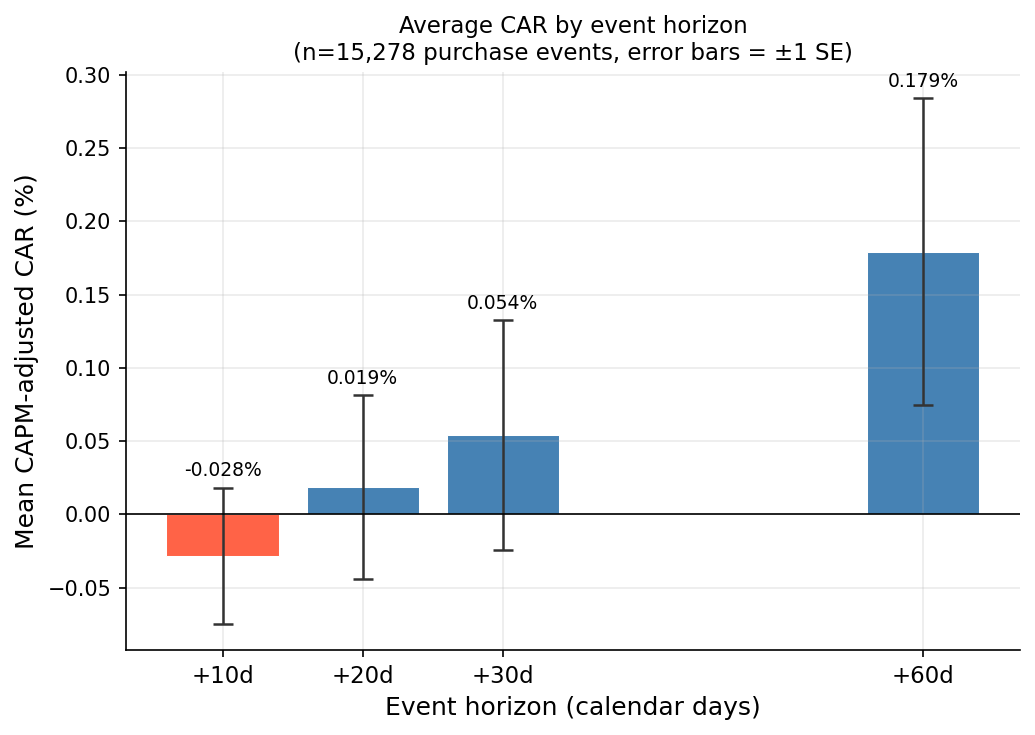

Saved plot_avg_car.png


In [ ]:
# ── Load data ──────────────────────────────────────────────
cov_clean   = np.load(rf'{DATA_DIR}\cov_clean.npy')
cov_tickers = pd.read_csv(rf'{DATA_DIR}\cov_tickers.csv')['ticker'].tolist()
mu_full     = pd.read_csv(rf'{DATA_DIR}\ticker_mu.csv', index_col=0)['mu']
pw          = pd.read_csv(rf'{DATA_DIR}\portfolio_weights.csv', index_col=0)
et          = pd.read_csv(rf'{DATA_DIR}\cleaned_congress_trades.csv')

# redo MP params (for first plot)
N       = len(cov_tickers)
T       = 3230
q       = N / T
sigma2  = np.trace(cov_clean) / N
lp      = sigma2 * (1 + np.sqrt(q)) ** 2
eigs    = np.linalg.eigvalsh(cov_clean)

# Optimization universe mu (for plot 3)
common = [t for t in cov_tickers if t in mu_full.index]
mu_universe = mu_full[common]
weights_full = pw['weight'].reindex(common).fillna(0)

# ============================================================
# PLOT 4 — Average CAR over event horizons
# ============================================================
car_cols   = ['car_10', 'car_20', 'car_30', 'car_60']
horizons   = [10, 20, 30, 60]
means      = [et[c].mean()  for c in car_cols]
ses        = [et[c].sem()   for c in car_cols]
n_obs      = len(et)

fig4, ax4 = plt.subplots(figsize=(7, 5))

bar_colors = ['steelblue' if m >= 0 else 'tomato' for m in means]
bars4 = ax4.bar(horizons, [m * 100 for m in means],
                width=8, color=bar_colors, edgecolor='white', linewidth=0.5,
                yerr=[s * 100 for s in ses],
                error_kw=dict(ecolor='#333333', capsize=5, capthick=1.2, elinewidth=1.2))

ax4.axhline(0, color='black', linewidth=0.8)
ax4.set_xticks(horizons)
ax4.set_xticklabels([f'+{h}d' for h in horizons], fontsize=11)
ax4.set_xlabel('Event horizon (calendar days)', fontsize=12)
ax4.set_ylabel('Mean CAPM-adjusted CAR (%)', fontsize=12)
ax4.set_title(f'Average CAR by event horizon\n'
              f'(n={n_obs:,} purchase events, error bars = ±1 SE)', fontsize=11)

# Annotate bars with mean plus/minus SE
for bar, m, s in zip(bars4, means, ses):
    ypos = bar.get_height() + s * 100 + 0.005
    ax4.text(bar.get_x() + bar.get_width() / 2, ypos,
             f'{m*100:.3f}%', ha='center', va='bottom', fontsize=9)

fig4.tight_layout()
fig4.savefig(rf'{DATA_DIR}\plot_avg_car.png', dpi=150)
plt.show()
print('Saved plot_avg_car.png')


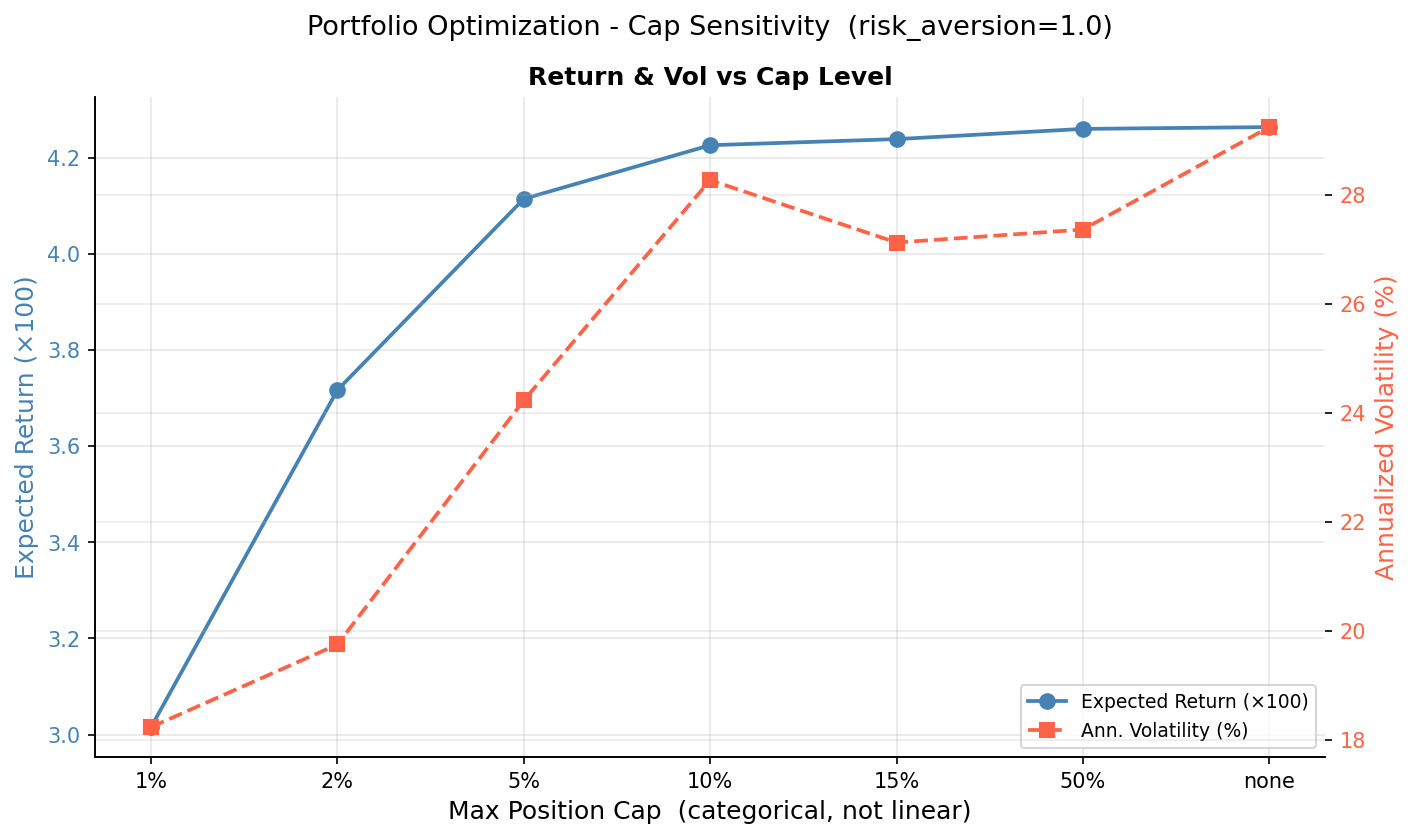

In [121]:
cov_clean   = np.load(rf'{DATA_DIR}\cov_clean.npy')
cov_tickers = pd.read_csv(rf'{DATA_DIR}\cov_tickers.csv')['ticker'].tolist()
mu_full     = pd.read_csv(rf'{DATA_DIR}\ticker_mu.csv', index_col=0)['mu']

common  = [t for t in cov_tickers if t in mu_full.index]
idx_map = [cov_tickers.index(t) for t in common]
mu_vec  = mu_full[common].values
sigma   = cov_clean[np.ix_(idx_map, idx_map)]
sigma   = (sigma + sigma.T) / 2
N       = len(mu_vec)

def solve_mv(max_weight, lam=1.0):
    w = cp.Variable(N)
    constraints = [cp.sum(w) == 1, w >= 0]
    if max_weight is not None:
        constraints.append(w <= max_weight)
    prob = cp.Problem(
        cp.Maximize(w @ mu_vec - (lam / 2) * cp.quad_form(w, cp.psd_wrap(sigma))),
        constraints
    )
    prob.solve(solver=cp.CLARABEL, verbose=False)
    if prob.status not in ('optimal', 'optimal_inaccurate') or w.value is None:
        return None
    wts = np.clip(w.value, 0, None)
    return wts / wts.sum()

# Cap labels shown on the plot
cap_values  = [0.01, 0.02, 0.05, 0.10, 0.15, 0.50, None]
cap_labels  = ['1%', '2%', '5%', '10%', '15%', '50%', 'none']

vols, rets, caps, n_active = [], [], [], []
ann = 252  # trading days
for cap, label in zip(cap_values, cap_labels):
    wts = solve_mv(cap)
    if wts is None:
        continue
    e_ret  = float(wts @ mu_vec)
    p_var  = float(wts @ sigma @ wts)
    vol    = float(np.sqrt(p_var * ann)) * 100
    n_pos  = int((wts > 0.001).sum())
    vols.append(vol)
    rets.append(e_ret * 100)
    caps.append(label)
    n_active.append(n_pos)

vols     = np.array(vols)
rets     = np.array(rets)
n_active = np.array(n_active)

fig, ax2 = plt.subplots(figsize=(10, 5.5))
ax2r = ax2.twinx()

x = np.arange(len(caps))
line_ret, = ax2.plot(x, rets, "o-", color="steelblue", lw=1.8, ms=7, label="Expected Return (×100)")
line_vol, = ax2r.plot(x, vols, "s--", color="tomato",    lw=1.8, ms=7, label="Ann. Volatility (%)")

ax2.set_xticks(x)
ax2.set_xticklabels(caps, fontsize=10)
ax2.set_xlabel("Max Position Cap  (categorical, not linear)", fontsize=12)
ax2.set_ylabel("Expected Return (×100)", color="steelblue", fontsize=12)
ax2r.set_ylabel("Annualized Volatility (%)", color="tomato", fontsize=12)
ax2.tick_params(axis="y", labelcolor="steelblue")
ax2r.tick_params(axis="y", labelcolor="tomato")
ax2.set_title("Return & Vol vs Cap Level", fontsize=12, fontweight="bold")
ax2.grid(True, alpha=0.3)

lines  = [line_ret, line_vol]
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, fontsize=9, loc="lower right")

fig.suptitle("Portfolio Optimization - Cap Sensitivity  (risk_aversion=1.0)", fontsize=13, y=1.02)
fig.subplots_adjust(left=0.09, right=0.91, top=0.92, bottom=0.12)
plt.show()


In [ ]:
# ── Load data once ─────────────────────────────────────────────────────────
print('Loading trades...')
trades_all = pd.read_csv(rf'{DATA_DIR}\cleaned_congress_trades.csv',
                         parse_dates=['transaction_date'])
trades_all['transaction_date'] = pd.to_datetime(trades_all['transaction_date'])

print('Loading prices...')
prices_raw = pd.read_csv(
    rf'{DATA_DIR}\all_stock_data.csv',
    usecols=['Date', 'Ticker', 'Close'],
    parse_dates=['Date'],
)
prices_raw.columns = ['date', 'ticker', 'close']
prices_raw = prices_raw[prices_raw['close'] > 0]
print(f'Price rows: {len(prices_raw):,}')

# Pivot to wide: date x ticker (use only dates from 2012 onwards for speed)
prices_wide = (
    prices_raw[prices_raw['date'] >= '2012-01-01']
    .pivot_table(index='date', columns='ticker', values='close', aggfunc='last')
)
prices_wide.sort_index(inplace=True)
print(f'Price matrix shape: {prices_wide.shape}')

# ── Amount map for size weights ─────────────────────────────────────────────
amount_map = {
    '$1,001 - $15,000':    (1_001,    15_000),
    '$15,001 - $50,000':   (15_001,   50_000),
    '$50,001 - $100,000':  (50_001,  100_000),
    '$100,001 - $250,000': (100_001, 250_000),
    '$250,001 - $500,000': (250_001, 500_000),
    '$500,001 - $1,000,000': (500_001, 1_000_000),
    '$1,000,001 - $5,000,000': (1_000_001, 5_000_000),
    '$5,000,001 - $25,000,000': (5_000_001, 25_000_000),
    '$25,000,001 - $50,000,000': (25_000_001, 50_000_000),
}
def size_weight(amt_str):
    r = amount_map.get(str(amt_str).strip())
    return np.log1p(np.sqrt(r[0] * r[1])) if r else 1.0

# ── mu pipeline for a given trade cutoff date ───────────────────────────────
LAMBDA_DECAY = 0.5  

def build_mu(trades_subset, formation_date=None):
    t = trades_subset.copy()
    if len(t) < 10:
        return pd.Series(dtype=float)

    t['w_size'] = t['trade_value'].apply(size_weight)

    member_mean = t.groupby('owner_name')['car_30'].mean()
    t['w_member'] = t['owner_name'].map(member_mean)
    t['w_member'] = (t['w_member'] - t['w_member'].mean()) + 1.0
    t['w_member'] = t['w_member'].clip(lower=0.01)

    def cluster_weight(grp):
        dates = grp['transaction_date'].values
        names = grp['owner_name'].values
        result = []
        for i in range(len(grp)):
            diff = np.abs((dates - dates[i]).astype('timedelta64[D]').astype(int))
            mask = (names != names[i]) & (diff <= 30)
            result.append(int(mask.sum()) + 1)
        return pd.Series(result, index=grp.index)

    t['w_cluster'] = t.groupby('ticker', group_keys=False).apply(cluster_weight, include_groups=False)

    # Exponential time decay: older trades downweighted by exp(-lambda * years_ago)
    if formation_date is not None:
        years_ago = (formation_date - t['transaction_date']).dt.days / 365.25
        t['w_decay'] = np.exp(-LAMBDA_DECAY * years_ago.clip(lower=0))
    else:
        t['w_decay'] = 1.0

    t['weight'] = t['w_size'] * t['w_member'] * t['w_cluster'] * t['w_decay']

    def weighted_stats(g):
        w = g['weight']
        return pd.Series({
            'raw_mu':    (w * g['car_30']).sum() / w.sum(),
            'n_events':  len(g),
            'n_members': g['owner_name'].nunique(),
            'car30_std': g['car_30'].std(),
        })

    ts = t.groupby('ticker', group_keys=False).apply(weighted_stats, include_groups=False)

    # filters
    ts = ts[ts['n_events']  >= 3]
    ts = ts[ts['n_members'] >= 3]
    sparse_noisy = (ts['n_events'] < 5) & (ts['car30_std'] >= 0.5)
    ts = ts[~sparse_noisy]
    if len(ts) < 5:
        return pd.Series(dtype=float)

    # Recency filter: zero out tickers with no purchase in the past 2 years
    if formation_date is not None:
        recency_cutoff = formation_date - pd.DateOffset(years=2)
        recent_tickers = set(
            trades_subset[trades_subset['transaction_date'] >= recency_cutoff]['ticker'].unique()
        )
        stale_mask = ~ts.index.isin(recent_tickers)
        ts = ts.copy()
        ts.loc[stale_mask, 'raw_mu'] = 0.0

    raw_mu_series = ts['raw_mu']
    mu_std_raw = float(raw_mu_series.std())
    tanh_mu = mu_std_raw * np.tanh(raw_mu_series / mu_std_raw)

    TARGET_VOL = 0.02
    mu = (tanh_mu - tanh_mu.mean()) / tanh_mu.std() * TARGET_VOL
    mu.name = 'mu'
    return mu

# ── Sigma pipeline for a 3-year window ─────────────────────────────────────
def build_sigma(tickers, end_date, years=3):
    start_date = end_date - pd.DateOffset(years=years)
    sub = prices_wide.loc[start_date:end_date, tickers]
    sub = sub.where(sub > 0)
    log_ret = np.log(sub / sub.shift(1)).iloc[1:]
    # drop tickers with >20% missing
    keep = log_ret.columns[log_ret.isna().mean() < 0.2]
    log_ret = log_ret[keep].dropna(how='all')
    if log_ret.shape[1] < 5 or log_ret.shape[0] < 60:
        return None, []
    log_ret = log_ret.fillna(0)
    lw = LedoitWolf().fit(log_ret.values)
    cov = lw.covariance_
    # RMT cleaning
    N, T = cov.shape[0], log_ret.shape[0]
    q = N / T
    eigvals, eigvecs = np.linalg.eigh(cov)
    sigma2 = np.trace(cov) / N
    lam_plus = sigma2 * (1 + np.sqrt(q)) ** 2
    noise = eigvals <= lam_plus
    eigvals_clean = eigvals.copy()
    eigvals_clean[noise] = eigvals[noise].mean()
    cov_clean = eigvecs @ np.diag(eigvals_clean) @ eigvecs.T
    cov_clean = (cov_clean + cov_clean.T) / 2
    return cov_clean, list(keep)

# ── Optimizer ──────────────────────────────────────────────────────────────
def solve_mv(mu_vec, sigma, cap=0.05, lam=1.0):
    N = len(mu_vec)
    w = cp.Variable(N)
    prob = cp.Problem(
        cp.Maximize(w @ mu_vec - (lam / 2) * cp.quad_form(w, cp.psd_wrap(sigma))),
        [cp.sum(w) == 1, w >= 0, w <= cap]
    )
    prob.solve(solver=cp.CLARABEL)
    if prob.status not in ('optimal', 'optimal_inaccurate'):
        return None
    wts = np.clip(w.value, 0, None)
    return wts / wts.sum()

# ── Forward return for year Y ───────────────────────────────────────────────
def forward_return(weights, tickers, year):
    start = pd.Timestamp(f'{year}-01-01')
    end   = pd.Timestamp(f'{year}-12-31')
    if tickers not in prices_wide.columns.tolist():
        pass  # handled per-ticker below
    port_ret = 0.0
    weight_used = 0.0
    for tkr, w in zip(tickers, weights):
        if tkr not in prices_wide.columns:
            continue
        col = prices_wide.loc[start:end, tkr].dropna()
        if len(col) < 2:
            continue
        ret = col.iloc[-1] / col.iloc[0] - 1
        port_ret   += w * ret
        weight_used += w
    if weight_used < 0.5:  # less than 50% of weight has price data
        return np.nan
    return port_ret / weight_used  # renormalise for missing tickers

def spy_return(year):
    start = pd.Timestamp(f'{year}-01-01')
    end   = pd.Timestamp(f'{year}-12-31')
    if 'SPY' not in prices_wide.columns:
        return np.nan
    col = prices_wide.loc[start:end, 'SPY'].dropna()
    if len(col) < 2:
        return np.nan
    return col.iloc[-1] / col.iloc[0] - 1

# ── Walk-forward loop ───────────────────────────────────────────────────────
years = list(range(2016, 2025))  # 2015 has too few prior events; 2024 prices only to Nov
results = []

print()
print('=' * 72)
print('WALK-FORWARD BACKTEST  (tanh + exp decay + recency filter)')
print('=' * 72)
print(f'  {"Year":<6} {"mu_tkrs":>8} {"cov_tkrs":>9} {"common":>7} '
      f'{"n_pos":>6} {"Port Ret":>10} {"SPY Ret":>10} {"Alpha":>10}')
print('  ' + '-' * 70)

for year in years:
    cutoff   = pd.Timestamp(f'{year}-01-01')
    cov_end  = pd.Timestamp(f'{year-1}-12-31')

    # 1. Build mu from all trades before cutoff
    trades_hist = trades_all[trades_all['transaction_date'] < cutoff]
    mu = build_mu(trades_hist, formation_date=cutoff)
    if len(mu) < 5:
        print(f'  {year}  insufficient mu tickers, skipping')
        continue

    # 2. Build Sigma from prior 3 years, restricted to mu tickers
    mu_tickers = mu.index.tolist()
    cov_candidates = [t for t in mu_tickers if t in prices_wide.columns]
    cov, cov_tickers_used = build_sigma(cov_candidates, cov_end, years=3)
    if cov is None:
        print(f'  {year}  insufficient covariance data, skipping')
        continue

    # 3. Intersect and align
    common = [t for t in cov_tickers_used if t in mu.index]
    if len(common) < 5:
        print(f'  {year}  too few common tickers ({len(common)}), skipping')
        continue
    idx_cov = [cov_tickers_used.index(t) for t in common]
    mu_vec  = mu[common].values
    sigma   = cov[np.ix_(idx_cov, idx_cov)]

    # 4. Optimize
    wts = solve_mv(mu_vec, sigma, cap=0.05, lam=1.0)
    if wts is None:
        print(f'  {year}  solver failed, skipping')
        continue

    # 5. Forward return
    port_ret = forward_return(wts, common, year)
    spy_ret  = spy_return(year)
    alpha    = (port_ret - spy_ret) if not (np.isnan(port_ret) or np.isnan(spy_ret)) else np.nan
    n_pos    = int((wts > 0.001).sum())

    print(f'  {year:<6} {len(mu):>8} {len(cov_tickers_used):>9} {len(common):>7} '
          f'{n_pos:>6} {port_ret*100:>9.2f}% {spy_ret*100:>9.2f}% {alpha*100:>9.2f}%')

    results.append({'year': year, 'port_ret': port_ret, 'spy_ret': spy_ret,
                    'alpha': alpha, 'n_pos': n_pos,
                    'mu_tickers': len(mu), 'common_tickers': len(common)})

if not results:
    print('No results — check data availability.')
    raise SystemExit

df_res = pd.DataFrame(results)
df_res.to_csv(rf'{DATA_DIR}\backtest_results_recency.csv', index=False)
print(f'\nSaved backtest_results.csv')

# ── Summary stats ──────────────────────────────────────────────────────────
print()
print(f'  Mean annual port return: {df_res["port_ret"].mean()*100:.2f}%')
print(f'  Mean annual SPY  return: {df_res["spy_ret"].mean()*100:.2f}%')
print(f'  Mean annual alpha:       {df_res["alpha"].mean()*100:.2f}%')
print(f'  Years outperforming SPY: {(df_res["alpha"] > 0).sum()} / {len(df_res)}')

# ── Annualised Sharpe ratio (rf = 2%) ──────────────────────────────────────
RF_ANNUAL = 0.02
port_excess = df_res['port_ret'] - RF_ANNUAL
spy_excess  = df_res['spy_ret']  - RF_ANNUAL
sharpe_port = port_excess.mean() / port_excess.std() if port_excess.std() > 0 else np.nan
sharpe_spy  = spy_excess.mean()  / spy_excess.std()  if spy_excess.std()  > 0 else np.nan
# Annualise: using annual returns already, so Sharpe is already on an annual basis
# (multiply by sqrt(1) since observations are yearly — no further scaling needed)
print()
print(f'  Sharpe ratio (rf=2%, annualised):')
print(f'    Strategy : {sharpe_port:.3f}')
print(f'    SPY      : {sharpe_spy:.3f}')

# ── Max drawdown from cumulative annual equity curve ──────────────────────
def max_drawdown(returns):
    cum = (1 + returns).cumprod()
    running_max = cum.cummax()
    dd = (cum - running_max) / running_max
    return float(dd.min())

mdd_port = max_drawdown(df_res['port_ret'])
mdd_spy  = max_drawdown(df_res['spy_ret'])
print()
print(f'  Max drawdown (peak-to-trough, annual equity curve):')
print(f'    Strategy : {mdd_port*100:.2f}%')
print(f'    SPY      : {mdd_spy*100:.2f}%')

# ── Mean alpha excluding 2022 ──────────────────────────────────────────────
df_ex22 = df_res[df_res['year'] != 2022]
mean_alpha_ex22 = df_ex22['alpha'].mean()
print()
print(f'  Mean alpha ex-2022 ({len(df_ex22)} years): {mean_alpha_ex22*100:.2f}%')
print(f'  Mean alpha incl. 2022:          {df_res["alpha"].mean()*100:.2f}%')


Loading trades...
Loading prices...
Price rows: 34,554,937
Price matrix shape: (3231, 9315)

WALK-FORWARD BACKTEST  (tanh + exp decay + recency filter)
  Year    mu_tkrs  cov_tkrs  common  n_pos   Port Ret    SPY Ret      Alpha
  ----------------------------------------------------------------------
  2016         47        45      45     20     14.79%     13.59%      1.20%
  2017         95        94      94     20     18.43%     20.78%     -2.35%
  2018        134       134     134     20      0.53%     -5.25%      5.78%
  2019        222       222     222     20     30.07%     31.09%     -1.02%
  2020        325       322     322     20     19.23%     17.24%      2.00%
  2021        445       436     436     20     40.29%     29.63%     10.66%
  2022        532       526     526     20    -36.83%    -19.95%    -16.88%
  2023        576       570     570     20     20.37%     24.81%     -4.44%
  2024        622       622     622     20     17.40%     20.70%     -3.30%

Saved backtest

Backtest rows    : 9
CAR trades       : 15,276
Portfolio tickers: 20
Cov matrix shape : (560, 560)


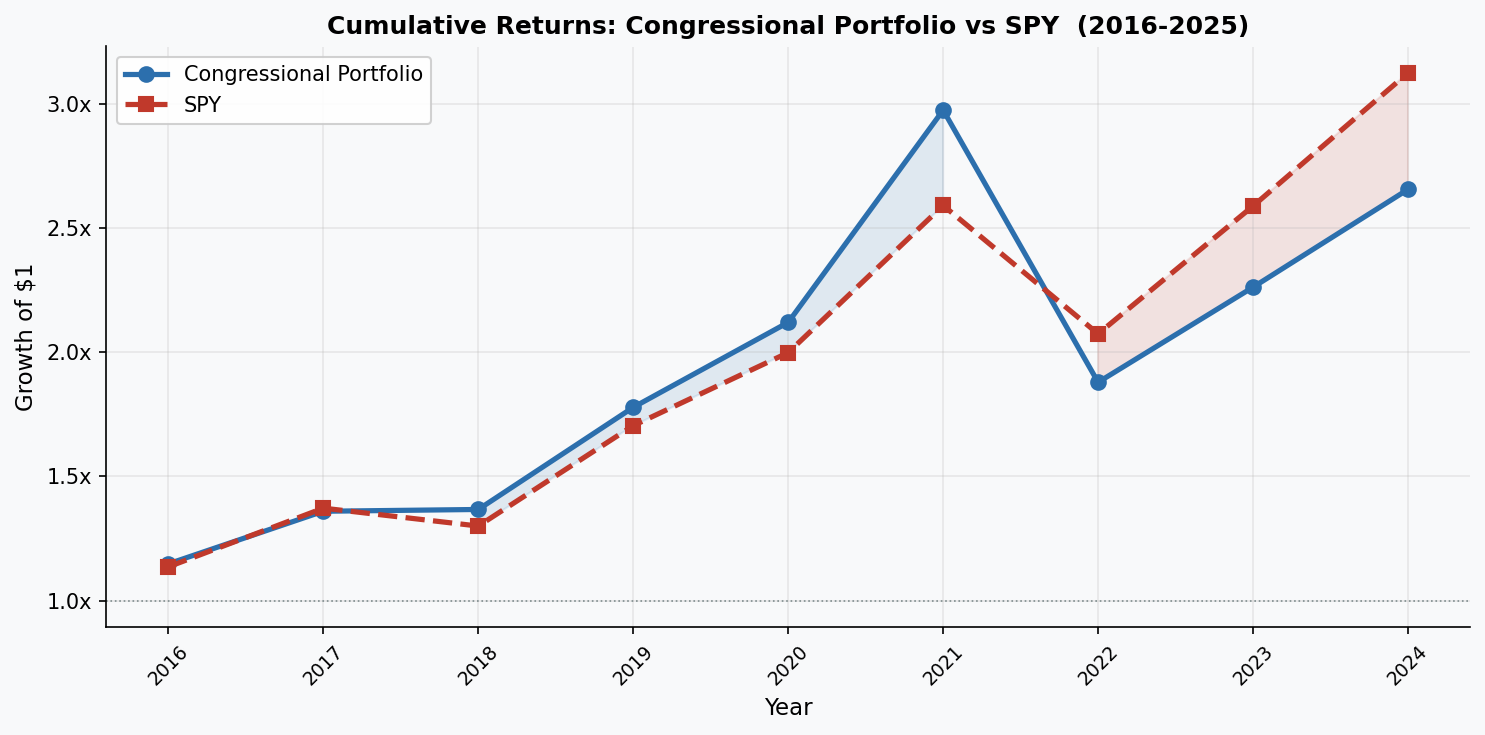

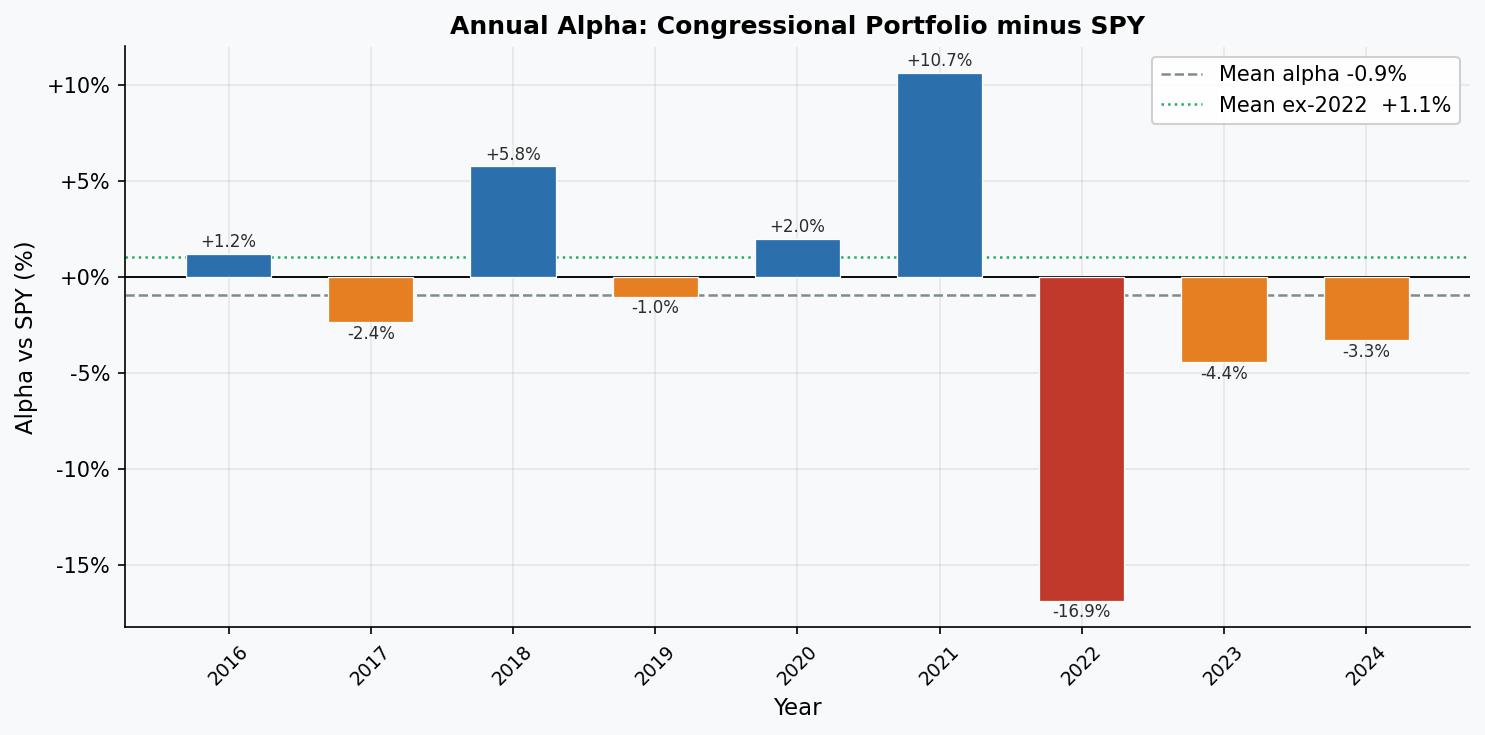

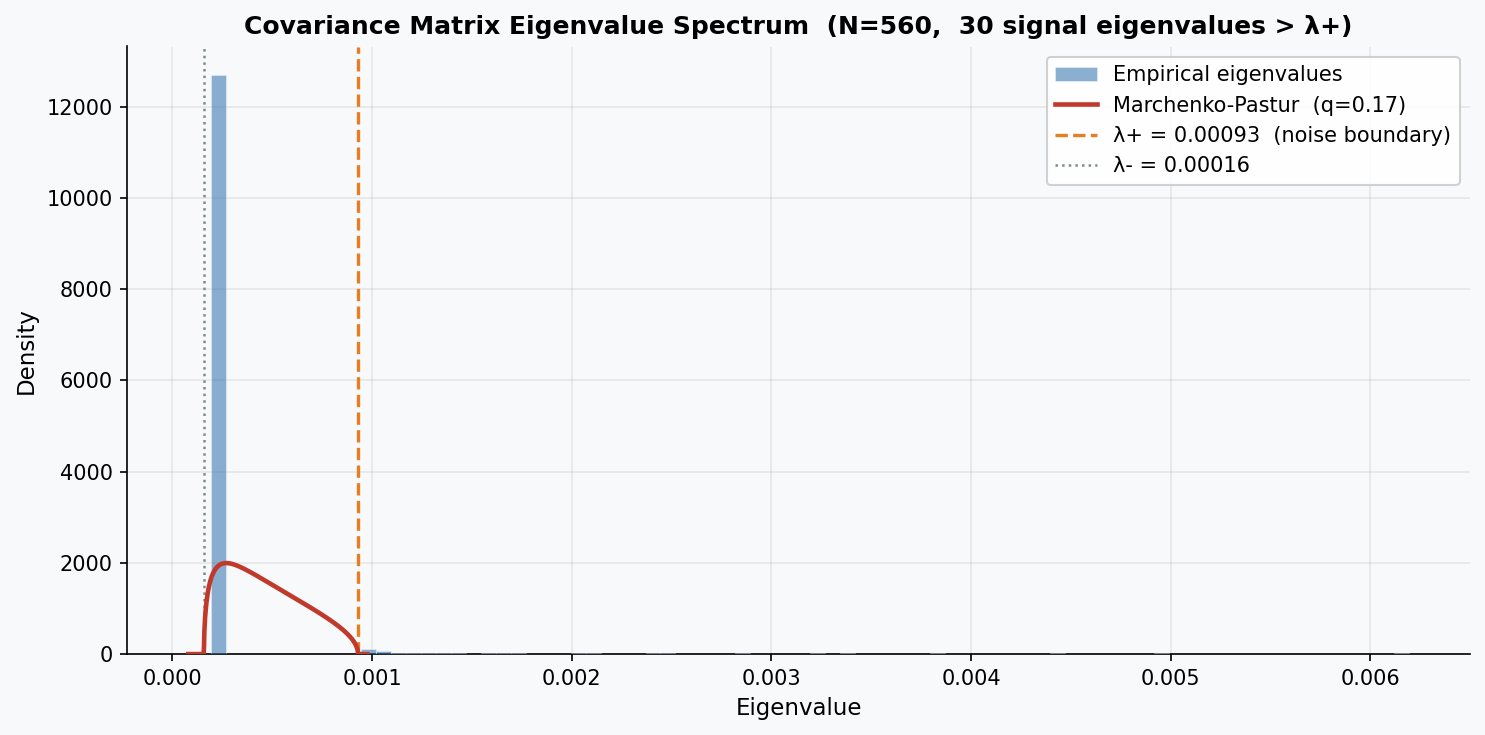

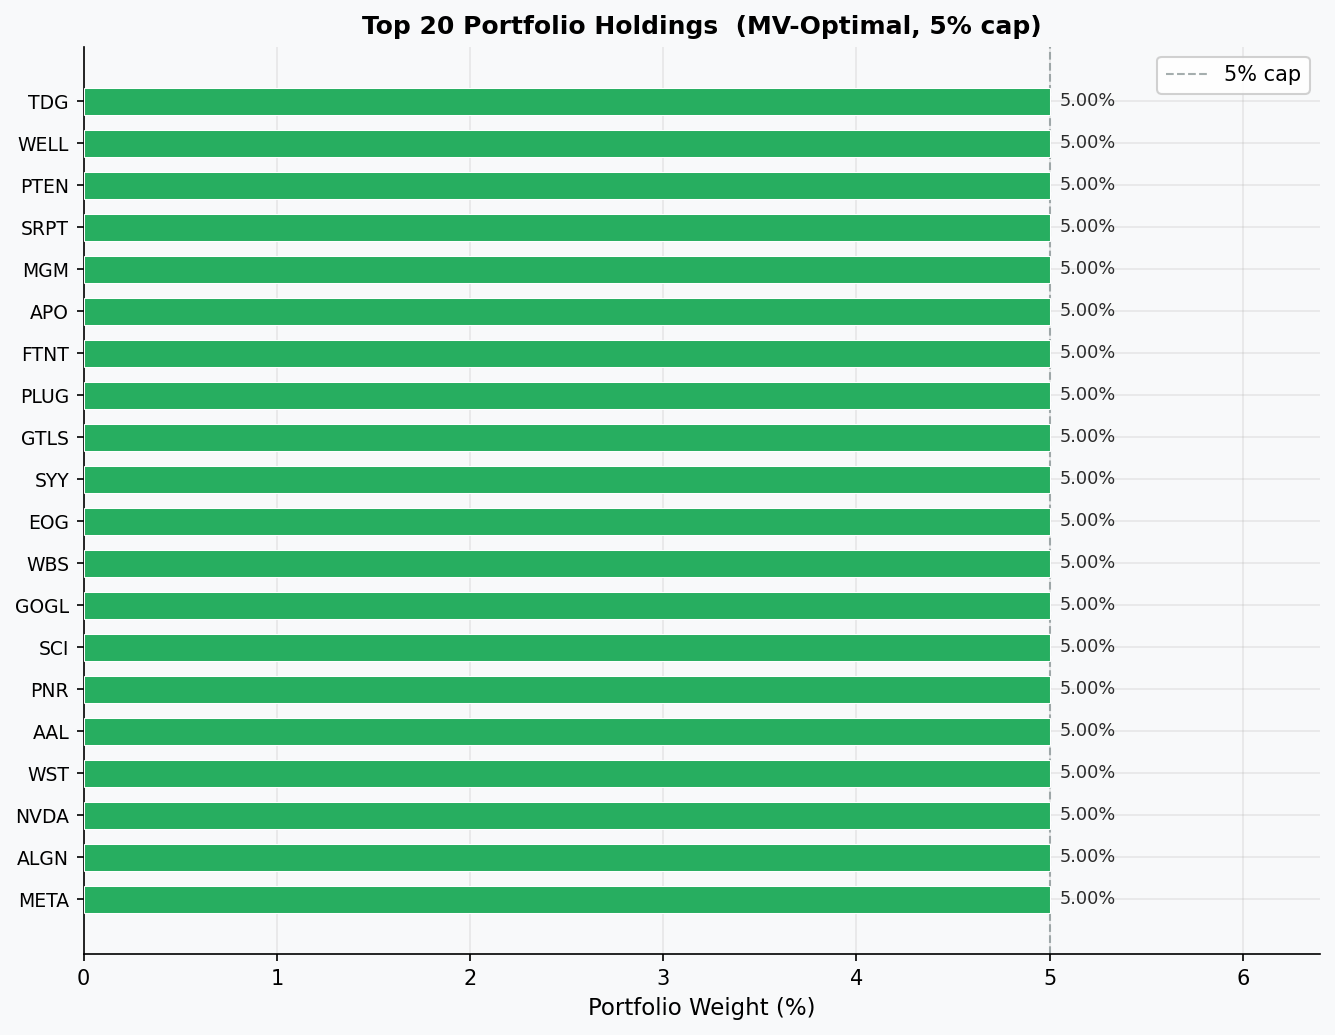

In [122]:
# ============================================================
# PLOTS  -- four publication-ready figures
#   1. Cumulative returns: strategy vs SPY
#   2. Year-by-year alpha bar chart (2022 highlighted red)
#   3. Eigenvalue histogram with Marchenko-Pastur bound
#   4. Top-20 portfolio holdings bar chart
#   5. CAR event study bar chart (horizons 10/20/30/60) with error bars  [removed]
# ============================================================
STYLE = {
    'blue':   '#2c6fad',
    'red':    '#c0392b',
    'grey':   '#7f8c8d',
    'green':  '#27ae60',
    'orange': '#e67e22',
    'bg':     '#f8f9fa',
}
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'figure.dpi': 150,
})

# -- Load shared data -------------------------------------------------------
df_bt  = pd.read_csv(rf'{DATA_DIR}\backtest_results_recency.csv')
df_car = pd.read_csv(rf'{DATA_DIR}\cleaned_congress_trades.csv',
                     parse_dates=['transaction_date'])
df_wts = pd.read_csv(rf'{DATA_DIR}\portfolio_weights.csv', index_col=0)
cov_matrix = np.load(rf'{DATA_DIR}\cov_clean.npy')

print(f'Backtest rows    : {len(df_bt)}')
print(f'CAR trades       : {len(df_car):,}')
print(f'Portfolio tickers: {len(df_wts)}')
print(f'Cov matrix shape : {cov_matrix.shape}')

# ==========================================================================
# FIGURE 1 -- Cumulative returns
# ==========================================================================
fig1, ax = plt.subplots(figsize=(10, 5))
fig1.patch.set_facecolor(STYLE['bg'])
ax.set_facecolor(STYLE['bg'])

port_cum = (1 + df_bt['port_ret']).cumprod()
spy_cum  = (1 + df_bt['spy_ret']).cumprod()

ax.plot(df_bt['year'], port_cum, 'o-', color=STYLE['blue'],
        lw=2.5, ms=7, label='Congressional Portfolio', zorder=3)
ax.plot(df_bt['year'], spy_cum, 's--', color=STYLE['red'],
        lw=2.5, ms=7, label='SPY', zorder=3)
ax.fill_between(df_bt['year'], port_cum, spy_cum,
                where=(port_cum >= spy_cum),
                alpha=0.12, color=STYLE['blue'])
ax.fill_between(df_bt['year'], port_cum, spy_cum,
                where=(port_cum < spy_cum),
                alpha=0.12, color=STYLE['red'])
ax.axhline(1.0, color=STYLE['grey'], lw=0.8, ls=':')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Growth of $1', fontsize=11)
ax.set_title('Cumulative Returns: Congressional Portfolio vs SPY  (2016-2025)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.9)
ax.set_xticks(df_bt['year'])
ax.set_xticklabels(df_bt['year'].astype(int), rotation=45, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1fx'))
fig1.tight_layout()
plt.show()

# ==========================================================================
# FIGURE 2 -- Alpha bar chart  (2022 highlighted red)
# ==========================================================================
fig2, ax = plt.subplots(figsize=(10, 5))
fig2.patch.set_facecolor(STYLE['bg'])
ax.set_facecolor(STYLE['bg'])

alpha_pct = df_bt['alpha'] * 100
bar_colors2 = [
    STYLE['red'] if y == 2022 else (STYLE['blue'] if a >= 0 else STYLE['orange'])
    for y, a in zip(df_bt['year'], alpha_pct)
]
bars2 = ax.bar(df_bt['year'], alpha_pct, color=bar_colors2,
               edgecolor='white', lw=0.6, width=0.6, zorder=3)
for bar, val in zip(bars2, alpha_pct):
    va     = 'bottom' if val >= 0 else 'top'
    offset = 0.15    if val >= 0 else -0.15
    ax.text(bar.get_x() + bar.get_width() / 2, val + offset,
            f'{val:+.1f}%', ha='center', va=va, fontsize=8, color='#2c2c2c')

ax.axhline(0, color='black', lw=0.9)
ax.axhline(alpha_pct.mean(), color=STYLE['grey'], lw=1.2, ls='--',
           label=f'Mean alpha {alpha_pct.mean():+.1f}%')
ex22_mean = alpha_pct[df_bt['year'] != 2022].mean()
ax.axhline(ex22_mean, color=STYLE['green'], lw=1.2, ls=':',
           label=f'Mean ex-2022  {ex22_mean:+.1f}%')

idx22 = df_bt.index[df_bt['year'] == 2022].tolist()
if idx22:
    val22 = float(alpha_pct.iloc[idx22[0]])

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Alpha vs SPY (%)', fontsize=11)
ax.set_title('Annual Alpha: Congressional Portfolio minus SPY', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.9)
ax.set_xticks(df_bt['year'])
ax.set_xticklabels(df_bt['year'].astype(int), rotation=45, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.0f%%'))
fig2.tight_layout()
plt.show()

# ==========================================================================
# FIGURE 3 -- Eigenvalue histogram + Marchenko-Pastur PDF
# ==========================================================================
eigvals  = np.linalg.eigvalsh(cov_matrix)
N        = 560
sigma2   = np.trace(cov_matrix) / N
T_approx = 3230
q_approx = N / T_approx
lam_plus  = sigma2 * (1 + np.sqrt(q_approx)) ** 2
lam_minus = sigma2 * (1 - np.sqrt(q_approx)) ** 2

def mp_pdf(x, s2, q):
    lp = s2 * (1 + np.sqrt(q)) ** 2
    lm = s2 * (1 - np.sqrt(q)) ** 2
    valid = (x >= lm) & (x <= lp)
    with np.errstate(divide='ignore', invalid='ignore'):
        pdf = np.where(valid,
                       np.sqrt(np.maximum((lp - x) * (x - lm), 0))
                       / (2 * np.pi * s2 * q * x), 0.0)
    return pdf

fig3, ax = plt.subplots(figsize=(10, 5))
fig3.patch.set_facecolor(STYLE['bg'])
ax.set_facecolor(STYLE['bg'])

ev_disp = eigvals[eigvals <= min(eigvals.max(), lam_plus * 8)]
ax.hist(ev_disp, bins=80, density=True, color=STYLE['blue'],
        alpha=0.55, edgecolor='white', lw=0.3, label='Empirical eigenvalues', zorder=3)

x_mp = np.linspace(max(float(lam_minus) * 0.5, 1e-8), float(lam_plus) * 1.05, 500)
ax.plot(x_mp, mp_pdf(x_mp, sigma2, q_approx), color=STYLE['red'], lw=2.2,
        label=f'Marchenko-Pastur  (q={q_approx:.2f})', zorder=4)
ax.axvline(lam_plus, color=STYLE['orange'], lw=1.6, ls='--',
           label=f'\u03bb+ = {lam_plus:.5f}  (noise boundary)')
if lam_minus > 0:
    ax.axvline(lam_minus, color=STYLE['grey'], lw=1.2, ls=':',
               label=f'\u03bb- = {lam_minus:.5f}')

n_signal = int((eigvals > lam_plus).sum())
ax.set_xlabel('Eigenvalue', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(f'Covariance Matrix Eigenvalue Spectrum  '
             f'(N={N},  {n_signal} signal eigenvalues > \u03bb+)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.9)
fig3.tight_layout()
plt.show()

# ==========================================================================
# FIGURE 4 -- Top-20 portfolio holdings
# ==========================================================================
top20 = df_wts.nlargest(20, 'weight').sort_values('weight', ascending=True)

fig4, ax = plt.subplots(figsize=(9, 7))
fig4.patch.set_facecolor(STYLE['bg'])
ax.set_facecolor(STYLE['bg'])

bar_colors4 = ([STYLE['green'] if m > 0 else STYLE['orange'] for m in top20['mu']]
               if 'mu' in top20.columns else [STYLE['blue']] * len(top20))
bars4 = ax.barh(top20.index, top20['weight'] * 100,
                color=bar_colors4, edgecolor='white', lw=0.5, height=0.65, zorder=3)
for bar, (_, row) in zip(bars4, top20.iterrows()):
    w = row['weight'] * 100
    ax.text(w + 0.05, bar.get_y() + bar.get_height() / 2,
            f'{w:.2f}%', va='center', fontsize=8.5, color='#2c2c2c')

ax.axvline(5.0, color=STYLE['grey'], lw=1, ls='--', alpha=0.7, label='5% cap')
ax.set_xlabel('Portfolio Weight (%)', fontsize=11)
ax.set_title('Top 20 Portfolio Holdings  (MV-Optimal, 5% cap)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.9)
ax.set_xlim(0, top20['weight'].max() * 100 * 1.28)
ax.tick_params(axis='y', labelsize=9)
fig4.tight_layout()
plt.show()
